<a href="https://colab.research.google.com/github/veeranna-spec/23CSBTB27/blob/main/Copy_of_HPC_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import time
import multiprocessing as mp
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate Dataset
# -----------------------------
def generate_dataset(n):
    data = []
    for i in range(n):
        base = random.randint(300000, 2000000)
        bonus = random.randint(50000, 500000)
        stocks = random.randint(10000, 1000000)
        ctc = base + bonus + stocks
        data.append((i, base, bonus, stocks, ctc))
    return pd.DataFrame(data, columns=["ID","Base","Bonus","Stocks","CTC"])

In [ ]:
def heavy_compute(x):
    total = 0
    for i in range(1000):   # CPU heavy loop
        total += (x * i) % 7
    return total



In [ ]:
# 3. Serial Execution
# -----------------------------
def serial_execution(df):
    start = time.time()

    df["Compute"] = df["CTC"].apply(heavy_compute)
    df_sorted = df.sort_values(by="CTC", ascending=False)

    end = time.time()
    return df_sorted, end - start

In [ ]:
def process_chunk(chunk):
    chunk["Compute"] = chunk["CTC"].apply(heavy_compute)
    return chunk


def parallel_execution(df, processes=4):
    start = time.time()

    chunks = []
    chunk_size = len(df) // processes

    for i in range(processes):
        chunks.append(df[i*chunk_size:(i+1)*chunk_size])

    with mp.Pool(processes) as pool:
        results = pool.map(process_chunk, chunks)

    df_parallel = pd.concat(results)
    df_sorted = df_parallel.sort_values(by="CTC", ascending=False)

    end = time.time()
    return df_sorted, end - start

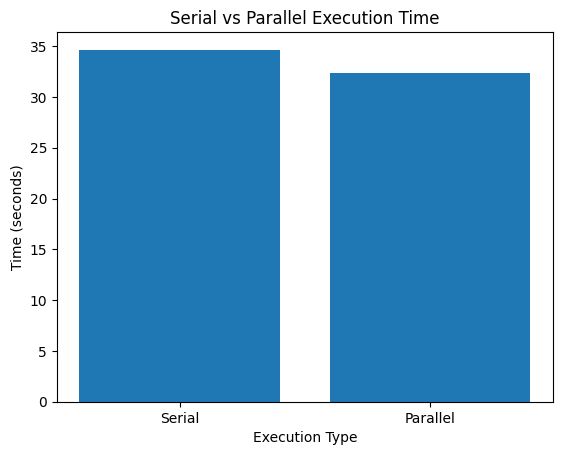

In [ ]:
# -----------------------------
if __name__ == "__main__":
    df = generate_dataset(300000)   # Large dataset

    # Serial
    serial_sorted, serial_time = serial_execution(df.copy())

    # Parallel
    parallel_sorted, parallel_time = parallel_execution(df.copy())

    # Speedup
    speedup = serial_time / parallel_time

    # Top 20 Employees
    top20 = serial_sorted.head(20)

    # -----------------------------
    # 6. Plot Graph
    # -----------------------------
    plt.figure()
    plt.bar(["Serial", "Parallel"], [serial_time, parallel_time])
    plt.xlabel("Execution Type")
    plt.ylabel("Time (seconds)")
    plt.title("Serial vs Parallel Execution Time")
    plt.show()


In [ ]:
# 7. Output Results
# -----------------------------
print("Serial Time:", serial_time)
print("Parallel Time:", parallel_time)
print("Speedup:", speedup)

print("\nTop 20 Employees by CTC:")
print(top20)

Serial Time: 34.643993854522705
Parallel Time: 32.339935541152954
Speedup: 1.0712449878088905

Top 20 Employees by CTC:
            ID     Base   Bonus  Stocks      CTC  Compute
143683  143683  1980434  499741  979523  3459698     3000
193649  193649  1991431  494902  969243  3455576     3001
104951  104951  1983981  493878  977445  3455304     3002
210684  210684  1998173  458474  997889  3454536     2997
66323    66323  1979564  482627  991835  3454026     2998
23946    23946  1987111  472715  993825  3453651     3001
44972    44972  1978092  491036  983252  3452380     2997
183796  183796  1989586  487906  971203  3448695     3001
283356  283356  1980836  479897  985220  3445953        0
49854    49854  1987027  461196  997321  3445544     3000
233485  233485  1991261  463411  989825  3444497        0
74828    74828  1988876  484254  968975  3442105     2998
243212  243212  1986028  455306  999043  3440377     2999
110296  110296  1983647  478881  977059  3439587     3000
14080    1